In [1]:
!pip install imbalanced-learn

In [2]:
!pip install xgboost

In [3]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier

In [4]:
df = pd.read_csv('fraud_oracle.csv')

df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [5]:
print(df.shape)

df.info()

df.describe()

(15420, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [6]:
df.isnull().sum()

,0
Month,0
WeekOfMonth,0
DayOfWeek,0
Make,0
AccidentArea,0
DayOfWeekClaimed,0
MonthClaimed,0
WeekOfMonthClaimed,0
Sex,0
MaritalStatus,0


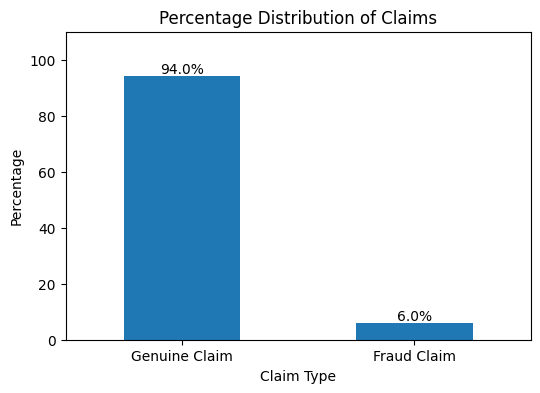

In [7]:
# Calculate fraud percentage
fraud_percent = (
    df['FraudFound_P']
    .value_counts(normalize=True)
    .sort_index() * 100
)

# Plot
plt.figure(figsize=(6,4))

ax = fraud_percent.plot(
    kind='bar'
)

# Custom labels
ax.set_xticklabels(
    ['Genuine Claim', 'Fraud Claim'],
    rotation=0
)

# Add percentage labels above bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Percentage Distribution of Claims")
plt.xlabel("Claim Type")
plt.ylabel("Percentage")

plt.ylim(0, 110)

plt.show()

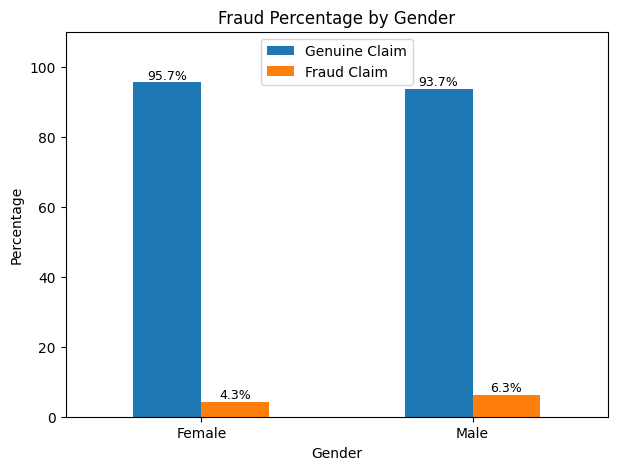

In [8]:
gender_fraud = pd.crosstab(
    df['Sex'],
    df['FraudFound_P'],
    normalize='index'
) * 100

ax = gender_fraud.plot(
    kind='bar',
    figsize=(7,5)
)

# Add percentage labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Fraud Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")

plt.xticks(
    ticks=[0,1],
    labels=['Female', 'Male'],
    rotation=0
)

plt.legend(['Genuine Claim', 'Fraud Claim'])

plt.ylim(0, 110)

plt.show()

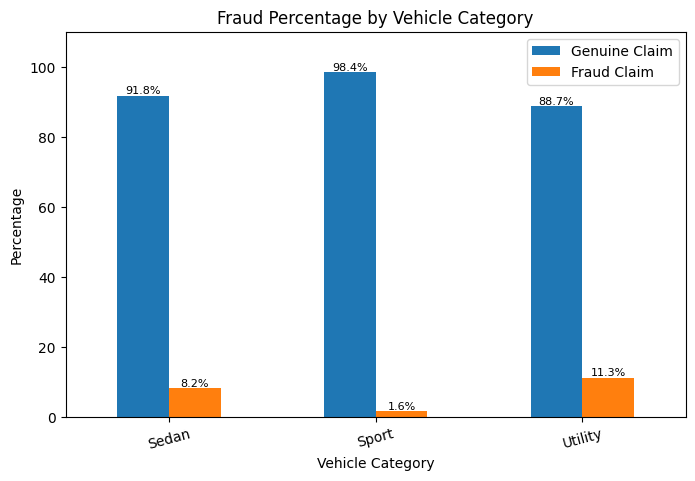

In [9]:
vehicle_fraud = pd.crosstab(
    df['VehicleCategory'],
    df['FraudFound_P'],
    normalize='index'
) * 100

ax = vehicle_fraud.plot(
    kind='bar',
    figsize=(8,5)
)

# Add labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Fraud Percentage by Vehicle Category")
plt.xlabel("Vehicle Category")
plt.ylabel("Percentage")

plt.legend(['Genuine Claim', 'Fraud Claim'])

plt.xticks(rotation=15)

plt.ylim(0, 110)

plt.show()

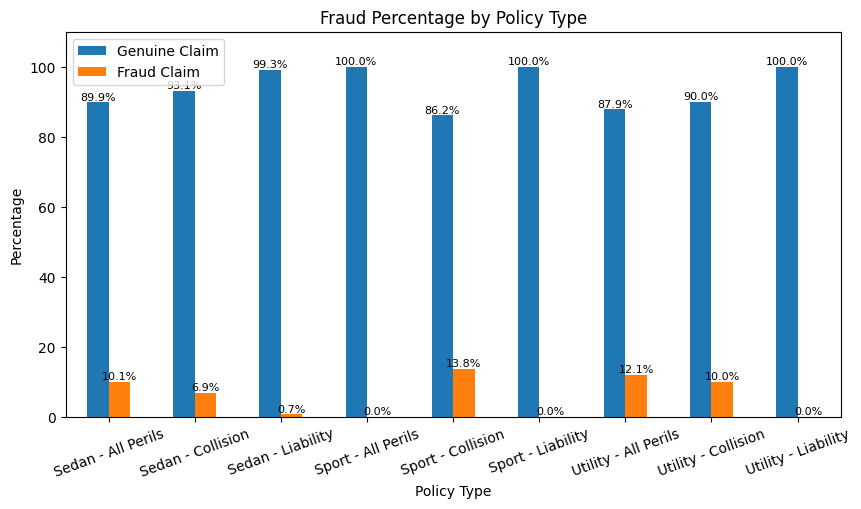

In [10]:
policy_fraud = pd.crosstab(
    df['PolicyType'],
    df['FraudFound_P'],
    normalize='index'
) * 100

ax = policy_fraud.plot(
    kind='bar',
    figsize=(10,5)
)

# Add labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Fraud Percentage by Policy Type")
plt.xlabel("Policy Type")
plt.ylabel("Percentage")

plt.legend(['Genuine Claim', 'Fraud Claim'])

plt.xticks(rotation=20)

plt.ylim(0, 110)

plt.show()

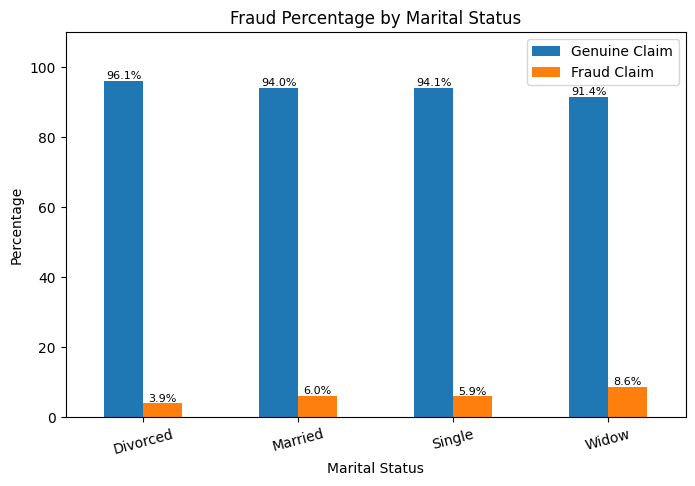

In [11]:
marital_fraud = pd.crosstab(
    df['MaritalStatus'],
    df['FraudFound_P'],
    normalize='index'
) * 100

ax = marital_fraud.plot(
    kind='bar',
    figsize=(8,5)
)

# Add labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Fraud Percentage by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Percentage")

plt.legend(['Genuine Claim', 'Fraud Claim'])

plt.xticks(rotation=15)

plt.ylim(0, 110)

plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

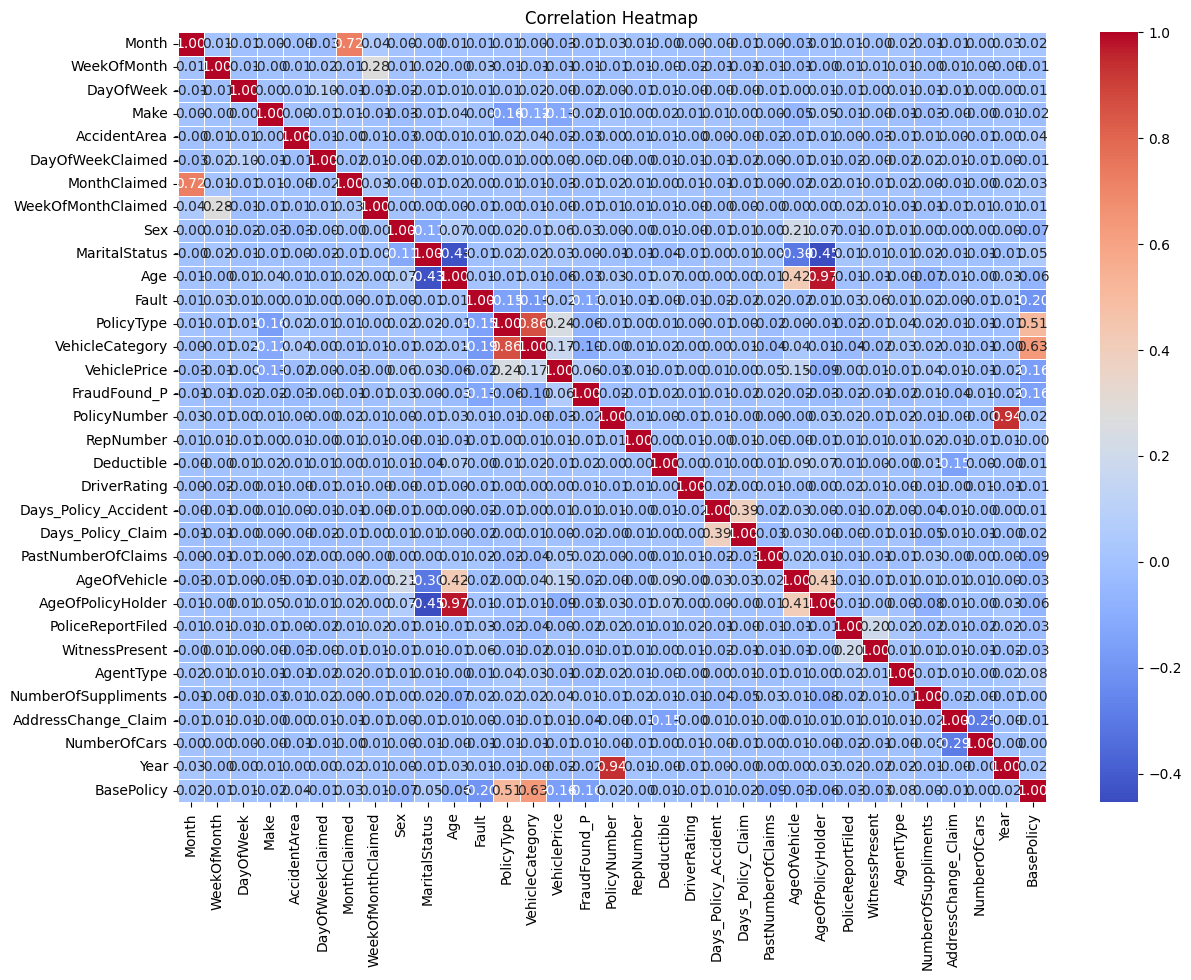

In [13]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [14]:
columns_to_drop = [
    'PolicyNumber',
    'RepNumber',
    'AddressChange_Claim',
    'DayOfWeekClaimed',
    'DayOfWeek'
]

df.drop(columns=columns_to_drop, inplace=True)

print("Updated Shape:", df.shape)

Updated Shape: (15420, 28)


In [15]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [16]:
X = df.drop('FraudFound_P', axis=1)

y = df['FraudFound_P']

In [17]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_resampled).value_counts())

Before SMOTE:
FraudFound_P
0    14497
1      923
Name: count, dtype: int64

After SMOTE:
FraudFound_P
0    14497
1    14497
Name: count, dtype: int64


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Logistic Regression

In [20]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.8277289187790998
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      2899
           1       0.79      0.89      0.84      2900

    accuracy                           0.83      5799
   macro avg       0.83      0.83      0.83      5799
weighted avg       0.83      0.83      0.83      5799



Decision Tree

In [21]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy:
0.9187790998448008
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      2899
           1       0.90      0.95      0.92      2900

    accuracy                           0.92      5799
   macro avg       0.92      0.92      0.92      5799
weighted avg       0.92      0.92      0.92      5799



Random Forest

In [22]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:
0.955682014140369
              precision    recall  f1-score   support

           0       0.97      0.94      0.96      2899
           1       0.94      0.97      0.96      2900

    accuracy                           0.96      5799
   macro avg       0.96      0.96      0.96      5799
weighted avg       0.96      0.96      0.96      5799



Confusion Matrix

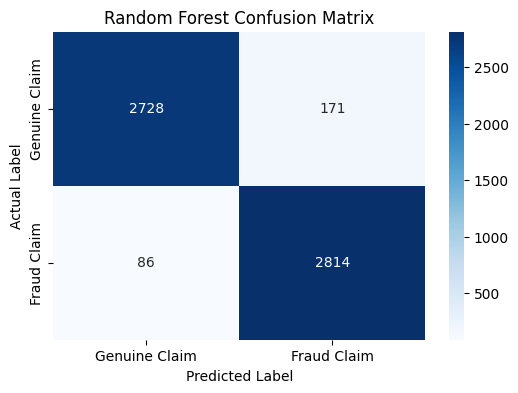

In [23]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Genuine Claim', 'Fraud Claim'],
    yticklabels=['Genuine Claim', 'Fraud Claim']
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

ANN

In [24]:
ann = Sequential()

# Input Layer
ann.add(Dense(units=64, activation='relu', input_dim=X_train_scaled.shape[1]))

# Hidden Layer
ann.add(Dense(units=32, activation='relu'))

# Dropout
ann.add(Dropout(0.3))

# Another Hidden Layer
ann.add(Dense(units=16, activation='relu'))

# Output Layer
ann.add(Dense(units=1, activation='sigmoid'))

In [25]:
ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = ann.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
580/580 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7976 - loss: 0.4314 - val_accuracy: 0.8388 - val_loss: 0.3593
Epoch 2/20
580/580 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8572 - loss: 0.3377 - val_accuracy: 0.8482 - val_loss: 0.3396
Epoch 3/20
580/580 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8679 - loss: 0.3142 - val_accuracy: 0.8616 - val_loss: 0.3256
Epoch 4/20
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8731 - loss: 0.2998 - val_accuracy: 0.8735 - val_loss: 0.3122
Epoch 5/20
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8808 - loss: 0.2888 - val_accuracy: 0.8782 - val_loss: 0.3050
Epoch 6/20
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8846 - loss: 0.2794 - val_accuracy: 0.8838 - val_loss: 0.2920
Epoch 7/20
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8922 - loss: 0.2693 - val_accuracy: 0.8789 - val_loss: 0.3012
Epoch 8/20
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8948 - loss: 0.2611 - val_accuracy: 0.

In [27]:
loss, accuracy = ann.evaluate(X_test_scaled, y_test)

print("ANN Accuracy:", accuracy)

182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9079 - loss: 0.2377
ANN Accuracy: 0.9079151749610901


In [28]:
y_pred_ann = ann.predict(X_test_scaled)

y_pred_ann = (y_pred_ann > 0.5)

print(classification_report(y_test, y_pred_ann))

182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      2899
           1       0.90      0.92      0.91      2900

    accuracy                           0.91      5799
   macro avg       0.91      0.91      0.91      5799
weighted avg       0.91      0.91      0.91      5799



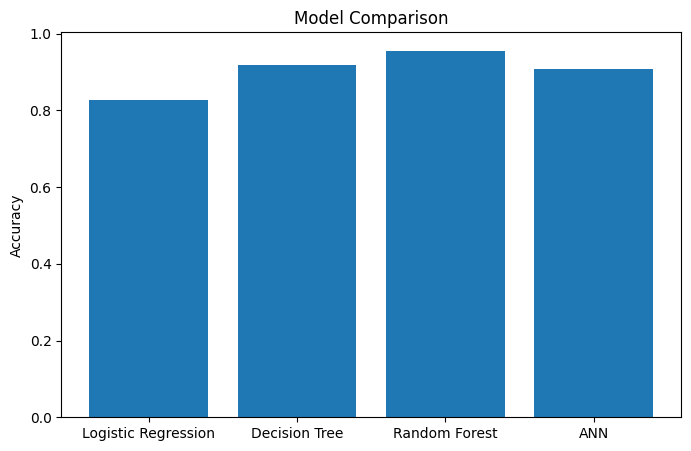

In [29]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'ANN']

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.show()

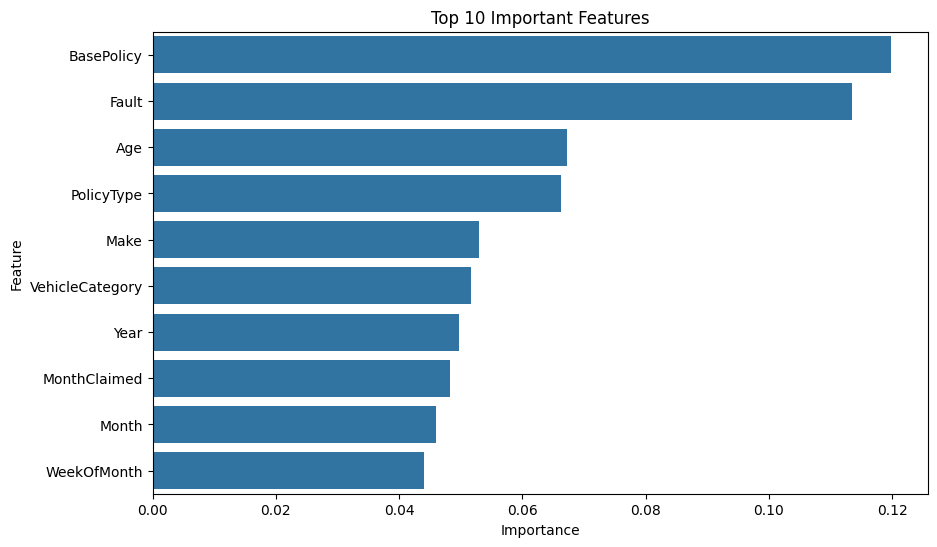

In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

XG Boost

In [31]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [32]:
print("XGBoost Accuracy:")

print(accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy:
0.9161924469736161

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.87      0.91      2899
           1       0.88      0.97      0.92      2900

    accuracy                           0.92      5799
   macro avg       0.92      0.92      0.92      5799
weighted avg       0.92      0.92      0.92      5799



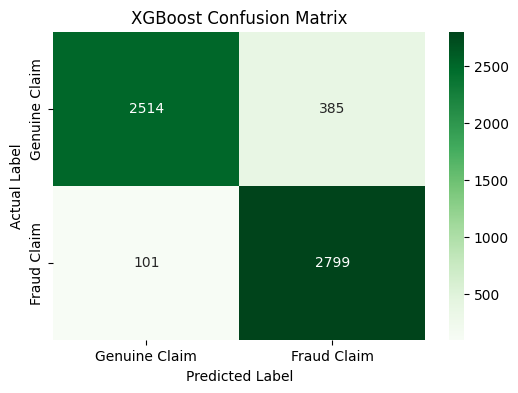

In [33]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Genuine Claim', 'Fraud Claim'],
    yticklabels=['Genuine Claim', 'Fraud Claim']
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

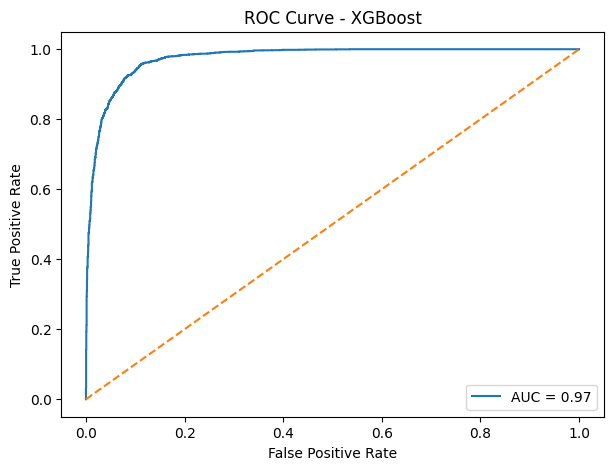

In [34]:
from sklearn.metrics import roc_curve, auc

# Prediction probabilities
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

# ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()

plt.show()

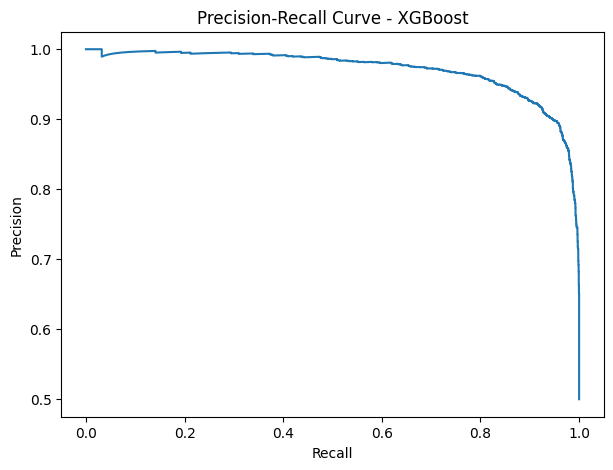

In [35]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve - XGBoost")

plt.show()

In [36]:
from sklearn.model_selection import cross_val_score

xgb_scores = cross_val_score(
    xgb,
    X_resampled,
    y_resampled,
    cv=5
)

print("Cross Validation Scores:")
print(xgb_scores)

print("\nAverage CV Score:")
print(xgb_scores.mean())

Cross Validation Scores:
[0.82152095 0.89101569 0.8815313  0.92412485 0.90720938]

Average CV Score:
0.8850804348812742


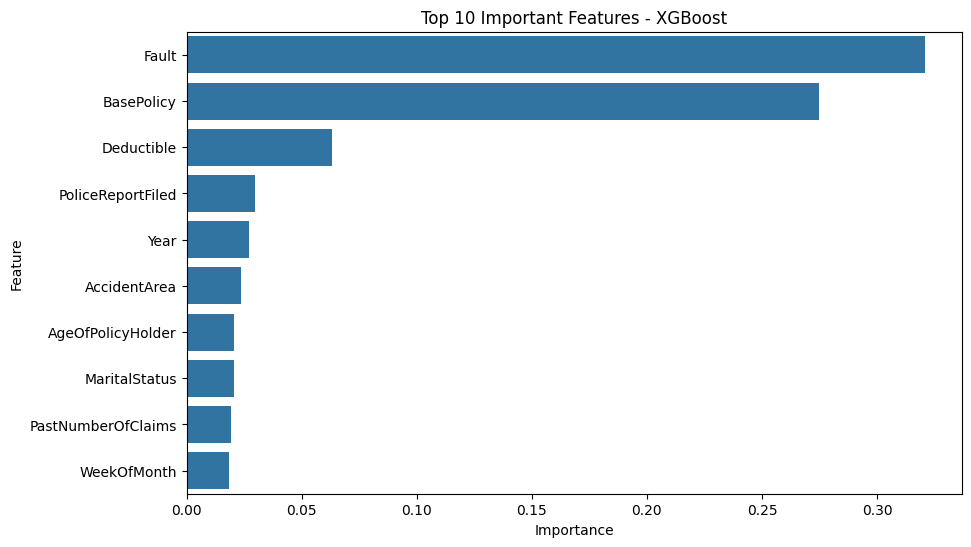

In [37]:
importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_xgb.head(10)
)

plt.title("Top 10 Important Features - XGBoost")

plt.show()

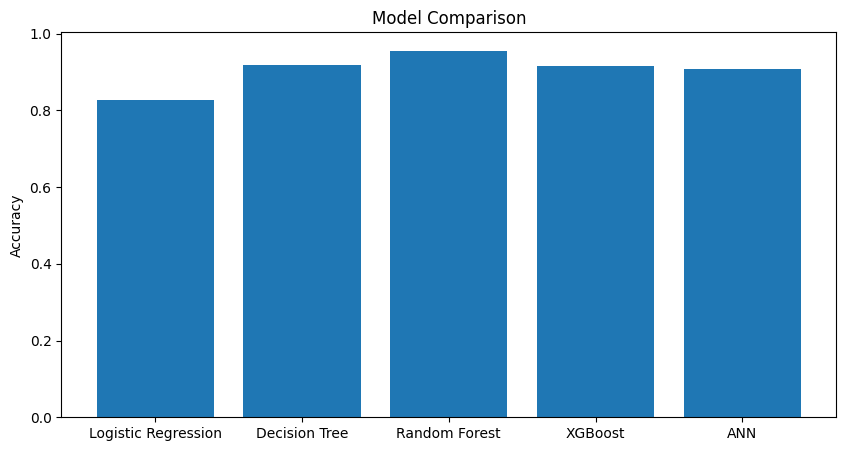

In [38]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost',
    'ANN'
]

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb),
    accuracy
]

plt.figure(figsize=(10,5))

plt.bar(models, accuracies)

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.show()

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Create comparison table
comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'ANN'
    ],

    'Accuracy': [

        accuracy_score(y_test, y_pred_lr),

        accuracy_score(y_test, y_pred_dt),

        accuracy_score(y_test, y_pred_rf),

        accuracy_score(y_test, y_pred_xgb),

        accuracy
    ],

    'Precision': [

        precision_score(y_test, y_pred_lr),

        precision_score(y_test, y_pred_dt),

        precision_score(y_test, y_pred_rf),

        precision_score(y_test, y_pred_xgb),

        precision_score(y_test, y_pred_ann)
    ],

    'Recall': [

        recall_score(y_test, y_pred_lr),

        recall_score(y_test, y_pred_dt),

        recall_score(y_test, y_pred_rf),

        recall_score(y_test, y_pred_xgb),

        recall_score(y_test, y_pred_ann)
    ],

    'F1-Score': [

        f1_score(y_test, y_pred_lr),

        f1_score(y_test, y_pred_dt),

        f1_score(y_test, y_pred_rf),

        f1_score(y_test, y_pred_xgb),

        f1_score(y_test, y_pred_ann)
    ]
})

# Round values
comparison = comparison.round(3)

# Display table
comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.828,0.794,0.886,0.837
1,Decision Tree,0.919,0.895,0.948,0.921
2,Random Forest,0.956,0.943,0.970,0.956
3,XGBoost,0.916,0.879,0.965,0.920
4,ANN,0.908,0.899,0.919,0.909


In [40]:
from sklearn.model_selection import RandomizedSearchCV

# Parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Random Search
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [41]:
best_rf = random_search.best_estimator_

best_rf.fit(X_train, y_train)

y_pred_best_rf = best_rf.predict(X_test)

print("Optimized Random Forest Accuracy:")

print(accuracy_score(y_test, y_pred_best_rf))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_best_rf))

Optimized Random Forest Accuracy:
0.9544749094671495

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.94      0.95      2899
           1       0.94      0.97      0.96      2900

    accuracy                           0.95      5799
   macro avg       0.95      0.95      0.95      5799
weighted avg       0.95      0.95      0.95      5799



In [42]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_best_rf)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9544721128569899


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create updated comparison table
comparison_updated = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Optimized Random Forest',
        'XGBoost',
        'ANN'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_best_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_ann)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_ann)
    ],

    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_ann)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_pred_dt),
        roc_auc_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_pred_best_rf),
        roc_auc_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_pred_ann)
    ]
})

# Round values
comparison_updated = comparison_updated.round(3)
comparison_updated.style.highlight_max(
    color='green',
    axis=0
)

# Display updated table
comparison_updated

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.828,0.794,0.886,0.837,0.828
1,Decision Tree,0.919,0.895,0.948,0.921,0.919
2,Random Forest,0.956,0.943,0.970,0.956,0.956
3,Optimized Random Forest,0.954,0.940,0.971,0.955,0.954
4,XGBoost,0.916,0.879,0.965,0.920,0.916
5,ANN,0.908,0.899,0.919,0.909,0.908


In [44]:
comparison_updated.style\
    .highlight_max(color='green', axis=0)\
    .set_properties(**{
        'text-align': 'center'
    })\
    .set_table_styles([
        {
            'selector': 'th',
            'props': [('text-align', 'center')]
        }
    ])

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.828000,0.794000,0.886000,0.837000,0.828000
1,Decision Tree,0.919000,0.895000,0.948000,0.921000,0.919000
2,Random Forest,0.956000,0.943000,0.970000,0.956000,0.956000
3,Optimized Random Forest,0.954000,0.940000,0.971000,0.955000,0.954000
4,XGBoost,0.916000,0.879000,0.965000,0.920000,0.916000
5,ANN,0.908000,0.899000,0.919000,0.909000,0.908000


In [45]:
import pickle

# Save model
pickle.dump(rf, open('fraud_model.pkl', 'wb'))

# Save scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("Model and scaler saved successfully")

Model and scaler saved successfully


In [46]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 64.6 MB/s eta 0:00:00


In [47]:
import streamlit as st
import pickle
import numpy as np

# Load model and scaler
model = pickle.load(open('fraud_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

# App title
st.title("Insurance Fraud Detection System")

st.write("Enter claim details to predict fraud risk.")

# Input fields
age = st.number_input("Age", min_value=18, max_value=100)

deductible = st.number_input("Deductible", min_value=0)

driver_rating = st.number_input("Driver Rating", min_value=1, max_value=5)

past_claims = st.number_input("Past Number of Claims", min_value=0)

# Prediction button
if st.button("Predict Fraud"):

    # Input array
    input_data = np.array([
        [
            age,
            deductible,
            driver_rating,
            past_claims
        ]
    ])

    # Scale input
    input_data = scaler.transform(input_data)

    # Prediction
    prediction = model.predict(input_data)

    # Probability
    probability = model.predict_proba(input_data)[0][1]

    # Output
    st.subheader(f"Fraud Probability: {probability*100:.2f}%")

    if prediction[0] == 1:
        st.error("Fraudulent Claim Detected")
    else:
        st.success("Genuine Claim")

    # Risk level
    if probability < 0.30:
        st.success("Low Fraud Risk")

    elif probability < 0.70:
        st.warning("Medium Fraud Risk")

    else:
        st.error("High Fraud Risk")

2026-05-14 04:47:01.494 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 04:47:01.908 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-14 04:47:01.911 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 04:47:01.913 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 04:47:01.915 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 04:47:01.917 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 04:47:01.918 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 04:47:01.920 Thread 'MainThread': mi

In [48]:
from google.colab import files

files.download('fraud_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
# Select important features

important_features = [
    'Fault',
    'BasePolicy',
    'Deductible',
    'PoliceReportFiled',
    'AccidentArea',
    'PastNumberOfClaims'
]

# Reduced dataset
X_reduced = X[important_features]

In [50]:
from sklearn.model_selection import train_test_split

X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_small = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_small.fit(
    X_train_small,
    y_train_small
)

RandomForestClassifier(random_state=42)

In [52]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_small = rf_small.predict(X_test_small)

print("Reduced Model Accuracy:")

print(accuracy_score(y_test_small, y_pred_small))

print("\nClassification Report:\n")

print(classification_report(
    y_test_small,
    y_pred_small
))

Reduced Model Accuracy:
0.9364461738002594

Classification Report:

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2887
           1       0.53      0.04      0.08       197

    accuracy                           0.94      3084
   macro avg       0.74      0.52      0.52      3084
weighted avg       0.91      0.94      0.91      3084



In [53]:
import pickle

# Save reduced model
pickle.dump(
    rf_small,
    open('fraud_model_small.pkl', 'wb')
)

print("Reduced Deployment Model Saved")

Reduced Deployment Model Saved


In [54]:
from google.colab import files

files.download('fraud_model_small.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
# Important features from XGBoost importance graph
important_features = [
    'Fault',
    'BasePolicy',
    'Deductible',
    'PoliceReportFiled',
    'AccidentArea',
    'PastNumberOfClaims'
]

# Reduced dataset
X_reduced = X[important_features]

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split data
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
rf_small = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_small.fit(X_train_small, y_train_small)

# Accuracy
pred_small = rf_small.predict(X_test_small)

print("Deployment Model Accuracy:")
print(accuracy_score(y_test_small, pred_small))

Deployment Model Accuracy:
0.9364461738002594


In [57]:
import pickle

pickle.dump(
    rf_small,
    open('fraud_model_small.pkl', 'wb')
)

print("Deployment model saved successfully")

Deployment model saved successfully


In [74]:
from google.colab import files

files.download('fraud_model_small.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
# Important features from XGBoost importance graph
important_features = [
    'Fault',
    'BasePolicy',
    'Deductible',
    'PoliceReportFiled',
    'AccidentArea',
    'PastNumberOfClaims'
]

# Reduced dataset
X_reduced = X[important_features]

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split data
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
rf_small = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_small.fit(X_train_small, y_train_small)

# Accuracy
pred_small = rf_small.predict(X_test_small)

print("Deployment Model Accuracy:")
print(accuracy_score(y_test_small, pred_small))

Deployment Model Accuracy:
0.9364461738002594


In [62]:
from google.colab import files

files.download('fraud_model_small.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
import pickle

pickle.dump(
    rf_small,
    open('fraud_model_small.pkl', 'wb')
)

print("Deployment model saved successfully")

Deployment model saved successfully
